

MANUALLY CORRECT PLIB14 samples as the subjects are _1 and _2
Same for PLib01, PLib02, PLib13, CSE01, CSE02, CSE13, CSE14, Blank01 - 08, 49 - 56




These 2 subjects D082062 and E045528 are on multiple plates. 
I think that the one of them needs to be removed from the data and manifest.

Drop these here in this script

manifest
```
D082062xxx,D082062,glioma serum,PLCO,case,73,M,15
D082062dupxxx,D082062,glioma serum,PLCO,case,73,M,15
E045528xxx,E045528,glioma serum,PLCO,case,63,M,16
E045528dupxxx,E045528,glioma serum,PLCO,case,63,M,16
```

data
```
D082062dupxxx,0,67,0,0,1,0,7,0,1,0,17,0,0,228,0,35
D082062xxx,0,2,0,0,4,0,9,0,0,0,9,0,0,0,0,0,0,7,0,1
E045528dupxxx,0,10,0,0,17,0,7,0,0,0,9,0,0,1,3,0,0,
E045528xxx,0,10,0,0,7,0,8,0,0,0,0,2,0,0,0,0,0,16,0
```


Separate the meta data

head -9 Counts.csv | datamash transpose -t, | tail -n +3 | cut -d, -f1,2,4- | sed '1isample,subject,type,study,group,age,sex,plate' | sed 's/Unnamed: [[:digit:]]\{1,2\}_level_.//g' > manifest.csv 



head -1 Counts.csv | cut -d, -f1,3- > tmp1.csv 

tail -n +10 Counts.csv | cut -d, -f1,3- >> tmp1.csv 

cat tmp1.csv | datamash transpose -t, > tmp2.csv

head -1 tmp2.csv > data.csv

tail -n +2 tmp2.csv | sort -t, -k1,1 >> data.csv

sed -i '1s/^id/sample/' data.csv


Just a matrix with peptide ids and sample ids.

In [1]:
%%time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
manifest = pd.read_csv('manifest.csv')
manifest = manifest[~manifest['sample'].isin(['D082062xxx','D082062dupxxx','E045528xxx','E045528dupxxx'])]

CPU times: user 1.99 s, sys: 371 ms, total: 2.36 s
Wall time: 2.72 s


In [2]:
manifest.shape

(1145, 8)

In [3]:
# Show the first few rows of each to inspect structure
manifest.head()


,sample,subject,type,study,group,age,sex,plate
0,14078-01,14078-01,glioma serum,IPS,case,60.0,M,1
1,14078-01dup,14078-01,glioma serum,IPS,case,60.0,M,1
2,14118-01,14118-01,glioma serum,IPS,case,61.0,M,1
3,14118-01dup,14118-01,glioma serum,IPS,case,61.0,M,1
4,14127-01,14127-01,glioma serum,IPS,case,63.0,M,1


In [4]:
%%time

data = pd.read_csv('data.csv')
data = data[~data['sample'].isin(['D082062xxx','D082062dupxxx','E045528xxx','E045528dupxxx'])]

CPU times: user 1min 15s, sys: 2.77 s, total: 1min 18s
Wall time: 1min 19s


In [5]:
data.shape

(1145, 115293)

In [6]:
data.head()


,sample,1,2,3,4,5,6,7,8,9,...,128278,128279,128280,128281,128282,128283,128284,128285,128286,128287
0,024JCM,0,0,0,0,1,0,53,0,0,...,0,0,0,0,1,0,0,0,2,0
1,024JCMdup,0,2,0,0,44,0,3,0,0,...,3,0,1,193,0,0,0,0,2,0
2,043MPL,0,20,0,0,23,0,31,0,0,...,0,0,0,20,6,4,0,4,3,0
3,043MPLdup,0,16,0,0,10,0,4,0,0,...,7,0,3,4,13,8,0,0,7,0
4,074KBP,0,0,0,0,31,0,52,0,18,...,0,0,0,0,0,0,1,0,39,7


In [7]:
# Use only relevant columns from manifest
manifest = manifest[['sample', 'subject', 'plate']]

# Classify samples based on sample/subject prefix
def classify_sample(row):
    if row['sample'].startswith('CSE') or row['subject'].startswith('CSE'):
        return 'control'
    elif row['sample'].startswith('Blank') or row['subject'].startswith('Blank'):
        return 'blank'
    elif row['sample'].startswith('PLib') or row['subject'].startswith('PLib'):
        return 'phage_library'
    else:
        return 'subject'

manifest['class'] = manifest.apply(classify_sample, axis=1)

# Align data: keep only samples present in both manifest and data
samples_in_both = set(manifest['sample']).intersection(set(data['sample']))
manifest = manifest[manifest['sample'].isin(samples_in_both)].reset_index(drop=True)
data = data[data['sample'].isin(samples_in_both)].reset_index(drop=True)

# Fill missing values in data with 0
data = data.fillna(0)

# Set sample as index for easier manipulation
data.set_index('sample', inplace=True)

# Merge manifest info into data for easy access
data_annot = data.copy()
data_annot['plate'] = data_annot.index.map(manifest.set_index('sample')['plate'])
data_annot['class'] = data_annot.index.map(manifest.set_index('sample')['class'])

# Show class distribution and a few rows
manifest['class'].value_counts(), data_annot.head()

(class
 subject          1004
 blank              93
 control            24
 phage_library      24
 Name: count, dtype: int64,
            1   2  3  4   5  6   7  8   9  10  ...  128280  128281  128282  \
 sample                                        ...                           
 024JCM     0   0  0  0   1  0  53  0   0   0  ...       0       0       1   
 024JCMdup  0   2  0  0  44  0   3  0   0   0  ...       1     193       0   
 043MPL     0  20  0  0  23  0  31  0   0   0  ...       0      20       6   
 043MPLdup  0  16  0  0  10  0   4  0   0   0  ...       3       4      13   
 074KBP     0   0  0  0  31  0  52  0  18   0  ...       0       0       0   
 
            128283  128284  128285  128286  128287  plate    class  
 sample                                                             
 024JCM          0       0       0       2       0     14  subject  
 024JCMdup       0       0       0       2       0     14  subject  
 043MPL          4       0       4       3       

In [8]:
import numpy as np

# Prepare for blank subtraction
data_blank_sub = data.copy()
data_blank_sub.head()

,1,2,3,4,5,6,7,8,9,10,...,128278,128279,128280,128281,128282,128283,128284,128285,128286,128287
sample,,,,,,,,,,,,,,,,,,,,,
024JCM,0,0,0,0,1,0,53,0,0,0,...,0,0,0,0,1,0,0,0,2,0
024JCMdup,0,2,0,0,44,0,3,0,0,0,...,3,0,1,193,0,0,0,0,2,0
043MPL,0,20,0,0,23,0,31,0,0,0,...,0,0,0,20,6,4,0,4,3,0
043MPLdup,0,16,0,0,10,0,4,0,0,0,...,7,0,3,4,13,8,0,0,7,0
074KBP,0,0,0,0,31,0,52,0,18,0,...,0,0,0,0,0,0,1,0,39,7


In [9]:
# my addition to avoid type warning
data_blank_sub = data_blank_sub.astype('float64')
data_blank_sub.head()

,1,2,3,4,5,6,7,8,9,10,...,128278,128279,128280,128281,128282,128283,128284,128285,128286,128287
sample,,,,,,,,,,,,,,,,,,,,,
024JCM,0.0,0.0,0.0,0.0,1.0,0.0,53.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0
024JCMdup,0.0,2.0,0.0,0.0,44.0,0.0,3.0,0.0,0.0,0.0,...,3.0,0.0,1.0,193.0,0.0,0.0,0.0,0.0,2.0,0.0
043MPL,0.0,20.0,0.0,0.0,23.0,0.0,31.0,0.0,0.0,0.0,...,0.0,0.0,0.0,20.0,6.0,4.0,0.0,4.0,3.0,0.0
043MPLdup,0.0,16.0,0.0,0.0,10.0,0.0,4.0,0.0,0.0,0.0,...,7.0,0.0,3.0,4.0,13.0,8.0,0.0,0.0,7.0,0.0
074KBP,0.0,0.0,0.0,0.0,31.0,0.0,52.0,0.0,18.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,39.0,7.0


In [10]:
%%time

# For each plate, subtract the median blank counts per peptide
for plate in manifest['plate'].unique():
    # Get blank samples for this plate
    blank_samples = manifest[(manifest['plate'] == plate) & (manifest['class'] == 'blank')]['sample']
    if len(blank_samples) == 0:
        continue  # skip if no blanks
    # Median blank counts for each peptide
    blank_median = data.loc[blank_samples].median(axis=0)
    # Subtract from all samples on this plate
    plate_samples = manifest[manifest['plate'] == plate]['sample']
    
    data_blank_sub.loc[plate_samples] = np.maximum(
        data.loc[plate_samples].values - blank_median.values, 0
    )

CPU times: user 4.56 s, sys: 467 ms, total: 5.02 s
Wall time: 5.03 s


In [11]:
# Add plate/class info for plotting
data_blank_sub_annot = data_blank_sub.copy()
data_blank_sub_annot['plate'] = data_blank_sub_annot.index.map(manifest.set_index('sample')['plate'])
data_blank_sub_annot['class'] = data_blank_sub_annot.index.map(manifest.set_index('sample')['class'])

# Show a few rows after blank subtraction
data_blank_sub_annot.head()

,1,2,3,4,5,6,7,8,9,10,...,128280,128281,128282,128283,128284,128285,128286,128287,plate,class
sample,,,,,,,,,,,,,,,,,,,,,
024JCM,0.0,0.0,0.0,0.0,0.0,0.0,53.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,14,subject
024JCMdup,0.0,2.0,0.0,0.0,43.0,0.0,3.0,0.0,0.0,0.0,...,1.0,193.0,0.0,0.0,0.0,0.0,2.0,0.0,14,subject
043MPL,0.0,20.0,0.0,0.0,22.0,0.0,30.0,0.0,0.0,0.0,...,0.0,20.0,6.0,2.0,0.0,4.0,3.0,0.0,13,subject
043MPLdup,0.0,16.0,0.0,0.0,9.0,0.0,3.0,0.0,0.0,0.0,...,3.0,4.0,13.0,6.0,0.0,0.0,7.0,0.0,13,subject
074KBP,0.0,0.0,0.0,0.0,30.0,0.0,52.0,0.0,18.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,39.0,7.0,14,subject


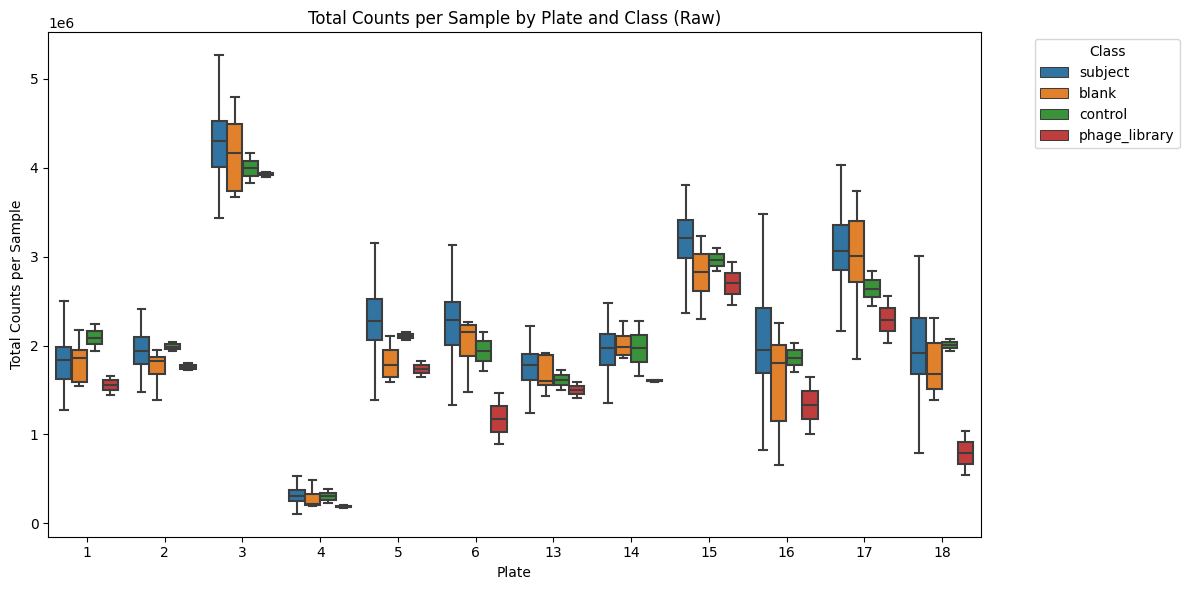

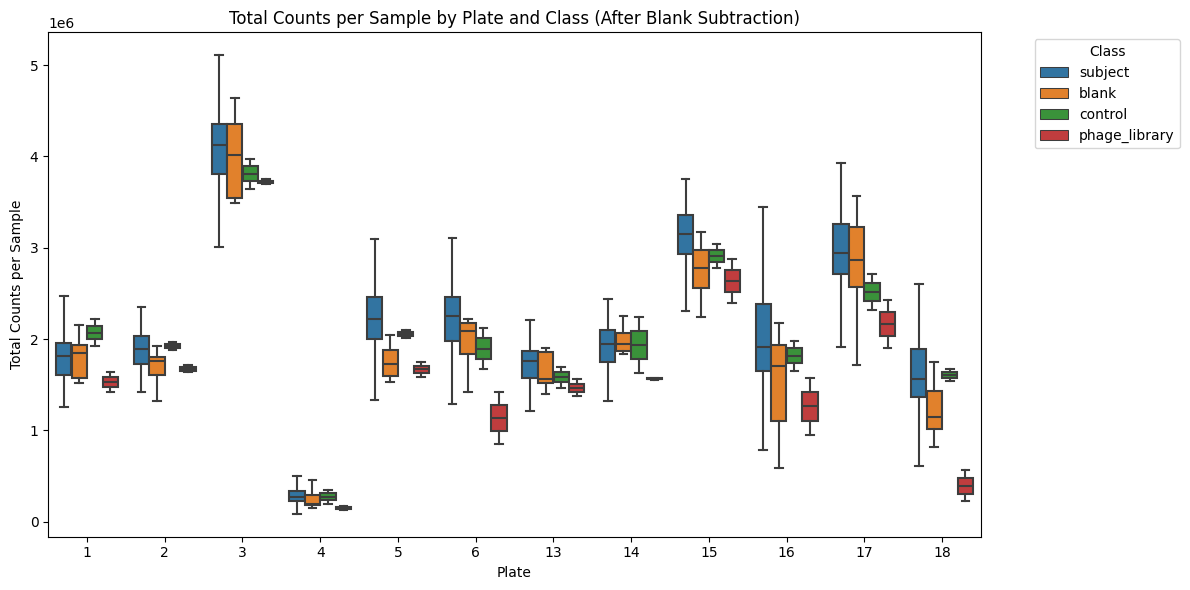

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_total_counts(data_annot, title):
    # Calculate total counts per sample
    total_counts = data_annot.drop(['plate', 'class'], axis=1).sum(axis=1)
    plot_df = pd.DataFrame({
        'total_counts': total_counts,
        'plate': data_annot['plate'],
        'class': data_annot['class']
    })
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='plate', y='total_counts', hue='class', data=plot_df, showfliers=False)
    plt.title(title)
    plt.ylabel('Total Counts per Sample')
    plt.xlabel('Plate')
    plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Before blank subtraction
plot_total_counts(data_annot, "Total Counts per Sample by Plate and Class (Raw)")

# After blank subtraction
plot_total_counts(data_blank_sub_annot, "Total Counts per Sample by Plate and Class (After Blank Subtraction)")

In [13]:
%%time

from sklearn.preprocessing import quantile_transform

# Function to quantile normalize within each plate
def quantile_normalize_within_plate(data, manifest):
    data_qn = data.copy()
    for plate in manifest['plate'].unique():
        plate_samples = manifest[manifest['plate'] == plate]['sample']
        plate_data = data_qn.loc[plate_samples]
        # Only normalize if more than 1 sample
        if plate_data.shape[0] > 1:
            # Quantile normalization (output values are floats)
            qn = quantile_transform(plate_data, axis=0, n_quantiles=min(1000, plate_data.shape[0]), copy=True, output_distribution='uniform')
            data_qn.loc[plate_samples] = qn
    return data_qn

# Apply quantile normalization after blank subtraction
data_qn = quantile_normalize_within_plate(data_blank_sub, manifest)


CPU times: user 2min 14s, sys: 759 ms, total: 2min 15s
Wall time: 2min 15s


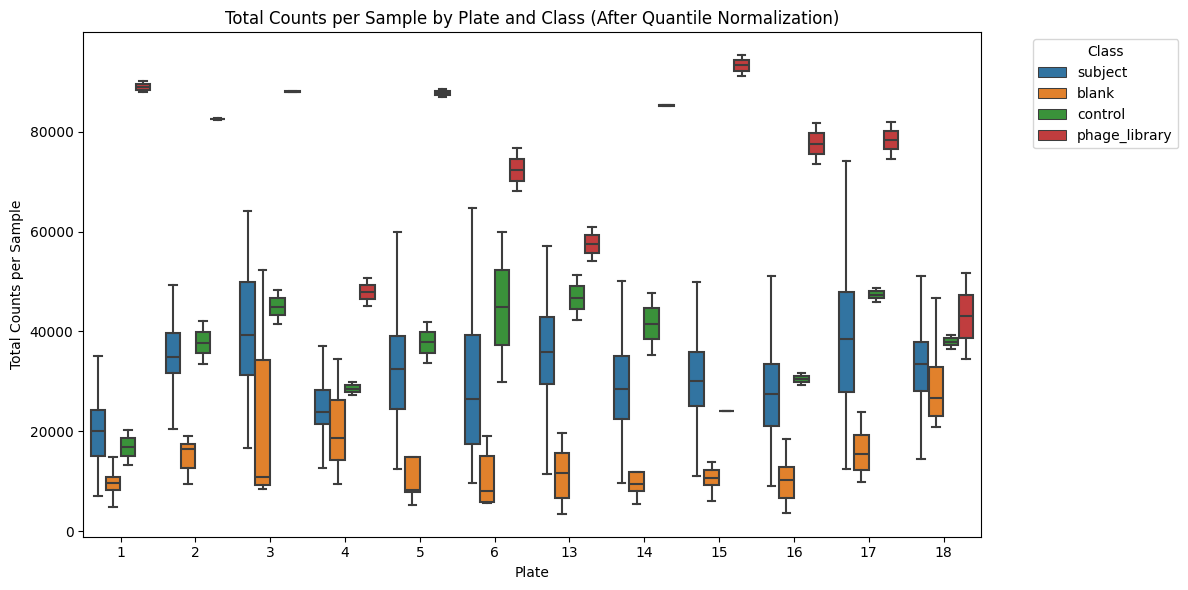

In [14]:
# Add plate/class info for plotting
data_qn_annot = data_qn.copy()
data_qn_annot['plate'] = data_qn_annot.index.map(manifest.set_index('sample')['plate'])
data_qn_annot['class'] = data_qn_annot.index.map(manifest.set_index('sample')['class'])

# Plot total counts after quantile normalization
plot_total_counts(data_qn_annot, "Total Counts per Sample by Plate and Class (After Quantile Normalization)")

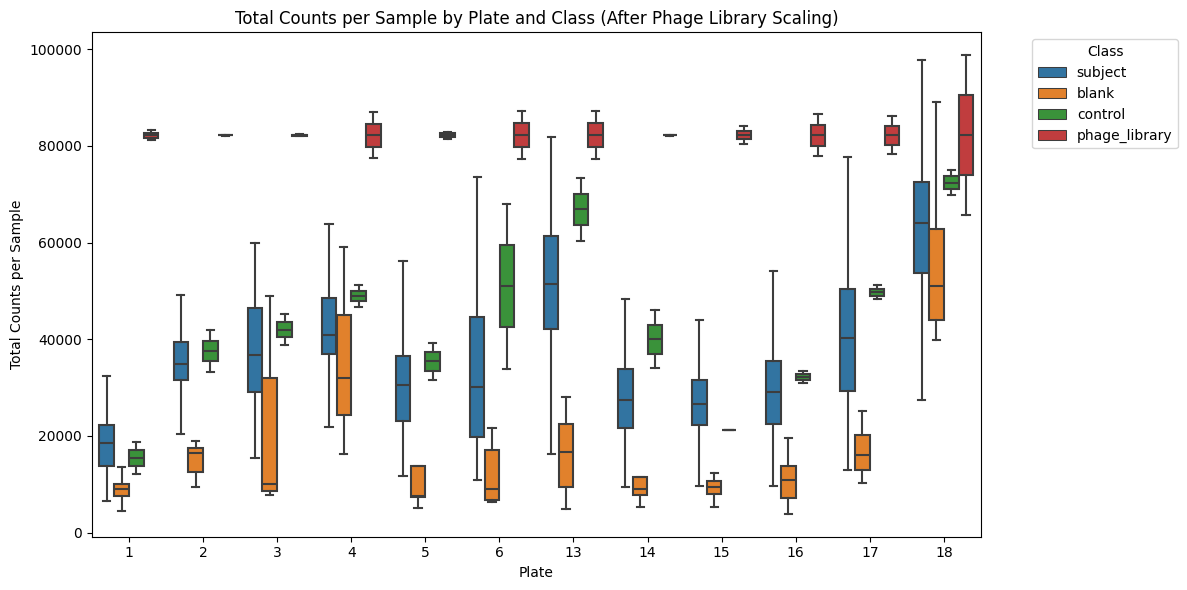

In [15]:
# Calculate scaling factors using phage library samples
phage_lib_samples = manifest[manifest['class'] == 'phage_library']
phage_lib_totals = data_qn.loc[phage_lib_samples['sample']].sum(axis=1)
phage_lib_by_plate = phage_lib_samples.copy()
phage_lib_by_plate['total'] = phage_lib_totals.values

# Median total per plate
plate_medians = phage_lib_by_plate.groupby('plate')['total'].median()
global_median = phage_lib_by_plate['total'].median()
scaling_factors = plate_medians / global_median

# Apply scaling to all samples on each plate
data_scaled = data_qn.copy()
for plate, scale in scaling_factors.items():
    plate_samples = manifest[manifest['plate'] == plate]['sample']
    data_scaled.loc[plate_samples] = data_qn.loc[plate_samples] / scale

# Add plate/class info for plotting
data_scaled_annot = data_scaled.copy()
data_scaled_annot['plate'] = data_scaled_annot.index.map(manifest.set_index('sample')['plate'])
data_scaled_annot['class'] = data_scaled_annot.index.map(manifest.set_index('sample')['class'])

# Plot total counts after phage library scaling
plot_total_counts(data_scaled_annot, "Total Counts per Sample by Plate and Class (After Phage Library Scaling)")

In [16]:
# Prepare data for ComBat: pycombat_seq expects samples as columns, features as rows
from inmoose.pycombat import pycombat_seq

# Remove annotation columns for ComBat
combat_input = data_scaled.copy()
combat_input = combat_input.astype(float)  # ensure float for pycombat_seq
combat_input_T = combat_input.T  # features as rows, samples as columns

In [17]:
# Plate batch vector
batch_vector = manifest.set_index('sample').loc[combat_input_T.columns]['plate'].values

In [18]:
batch_vector

array([14, 14, 13, ..., 17, 18, 18], shape=(1145,))

In [19]:
np.isnan(combat_input_T).sum().sum()

np.int64(0)

In [20]:
np.max(combat_input_T)

np.float64(1.910830612927679)

In [21]:
np.min(combat_input_T)

np.float64(0.0)

In [22]:
combat_input_T

sample,024JCM,024JCMdup,043MPL,043MPLdup,074KBP,074KBPdup,101VKC,101VKCdup,108741,108741dup,...,PLib14_1,PLib14_2,PLib15,PLib15dup,PLib16,PLib16dup,PLib17,PLib17dup,PLib18,PLib18dup
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.928487,0.000000,0.881614,0.872135,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.669729,1.102942,1.019271,0.000000,0.000000,0.0,0.593307,0.768852,0.000000,...,0.953856,0.964003,0.815256,0.824736,0.979575,0.968185,0.994832,0.950617,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.964003,0.000000,0.881614,0.000000,0.000000,0.000000,1.039047,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.964003,0.953856,0.881614,0.872135,1.059308,1.047917,1.000359,1.000359,1.669463,1.770033
5,0.000000,0.750908,0.912780,0.646552,0.700171,0.497223,0.0,0.403144,0.546740,0.643558,...,0.837161,0.821940,0.739418,0.729939,0.979575,0.945404,0.911929,0.851134,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128283,0.000000,0.000000,1.064910,1.255072,0.000000,0.918340,0.0,0.000000,0.888452,1.002356,...,0.816866,0.852382,0.853175,0.824736,1.002356,0.842890,0.934037,0.856661,1.820318,1.498493
128284,0.000000,0.000000,0.000000,0.000000,0.786424,0.000000,0.0,0.000000,0.000000,0.000000,...,0.786424,0.837161,0.801037,0.834216,0.956794,0.945404,0.674275,0.867715,0.000000,0.000000
128285,0.000000,0.000000,1.186614,0.000000,0.000000,0.796571,0.0,0.000000,0.000000,0.000000,...,0.887898,0.796571,0.824736,0.805776,0.000000,0.000000,0.729543,0.574792,0.000000,1.729805
128286,0.679876,0.679876,0.988845,1.186614,0.943708,0.816866,0.0,1.118155,0.871366,0.899842,...,0.598697,0.715392,0.805776,0.744158,0.000000,0.774548,0.878768,0.685329,0.985586,0.000000


In [23]:
%%time

# Apply ComBat-seq
#combat_corrected = pycombat_seq(combat_input_T, batch_vector)

#crashes

CPU times: user 3 μs, sys: 1 μs, total: 4 μs
Wall time: 7.15 μs


pycombat_seq(combat_input_T, batch_vector) output ....

Not clear why this happens

```
[WARNING] library size of zero detected
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[33], line 2
      1 # Apply ComBat-seq
----> 2 combat_corrected_will_crash = pycombat_seq(combat_input_T, batch_vector)

File ~/Library/Python/3.11/lib/python/site-packages/inmoose/pycombat/pycombat_seq.py:169, in pycombat_seq(counts, batch, covar_mod, shrink, shrink_disp, gene_subset_n, ref_batch, na_cov_action)
    166 # new offset - gene background expression (dge_obj.getOffset() is the same as log(dge_obj.samples.lib_size)
    167 new_offset += vec2mat(alpha_g, counts.shape[1])
--> 169 glm_f2 = glmFit(
    170     dge_obj.counts,
    171     design=design,
    172     dispersion=phi_matrix,
    173     offset=new_offset,
    174     prior_count=1e-4,
    175 )
    177 gamma_hat = glm_f2.coefficients[:, range(n_batch)]
    178 mu_hat = glm_f2.fitted_values

File ~/Library/Python/3.11/lib/python/site-packages/inmoose/edgepy/glmFit.py:278, in glmFit(y, design, dispersion, offset, lib_size, weights, prior_count, start)
    276 if prior_count > 0:
    277     fit.unshrunk_coefficients = fit.coefficients
--> 278     fit.coefficients = predFC(
    279         y,
    280         design,
    281         offset=offset,
    282         dispersion=dispersion_mat,
    283         prior_count=prior_count,
    284         weights=weights,
    285     ) * np.log(2)
    287 # counts N,M
    288 # design M,P
    289 assert y.shape[1] == design.shape[0]

File ~/Library/Python/3.11/lib/python/site-packages/inmoose/edgepy/predFC.py:128, in predFC(y, design, prior_count, offset, dispersion, weights)
    125 design = np.asarray(design)
    127 # Return matrix of coefficients on log2 scale
--> 128 g = glmFit(
    129     out_y,
    130     design,
    131     offset=out_offset,
    132     dispersion=dispersion,
    133     prior_count=0,
    134     weights=weights,
    135 )
    136 return g.coefficients / np.log(2)

File ~/Library/Python/3.11/lib/python/site-packages/inmoose/edgepy/glmFit.py:246, in glmFit(y, design, dispersion, offset, lib_size, weights, prior_count, start)
    244 group = designAsFactor(design)
    245 if group.nlevels() == design.shape[1]:
--> 246     (coef, fitted_values) = mglmOneWay(
    247         y,
    248         design=design,
    249         group=group,
    250         dispersion=dispersion_mat,
    251         offset=offset,
    252         weights=weights,
    253         coef_start=start,
    254     )
    255     deviance = nbinomDeviance(
    256         y=y, mean=fitted_values, dispersion=dispersion_mat, weights=weights
    257     )
    258     fit_method = "oneway"

File ~/Library/Python/3.11/lib/python/site-packages/inmoose/edgepy/mglmOneWay.py:191, in mglmOneWay(y, design, group, dispersion, offset, weights, coef_start, maxit, tol)
    189 for g in range(ngroups):
    190     j = np.nonzero(i == levg[g])[0]
--> 191     beta[:, g] = mglmOneGroup(
    192         y[:, j],
    193         dispersion=dispersion[:, j],
    194         offset=offset[:, j],
    195         weights=weights[:, j] if weights is not None else None,
    196         coef_start=coef_start[:, g] if coef_start is not None else None,
    197         maxit=maxit,
    198         tol=tol,
    199     )
    201 # Reset -inf values to finite values to simplify calculations downstream
    202 beta = np.where(beta > -1e8, beta, -1e8)

File ~/Library/Python/3.11/lib/python/site-packages/inmoose/edgepy/mglmOneGroup.py:99, in mglmOneGroup(y, dispersion, offset, weights, coef_start, maxit, tol, verbose)
     44 """
     45 Fit single-group negative-binomial GLMs genewise.
     46 
   (...)     95     vector of coefficients
     96 """
     97 # Check y
     98 # TODO check that y is a matrix and numeric
---> 99 _isAllZero(y)
    101 # Check dispersion
    102 dispersion = _compressDispersions(y, dispersion)

File ~/Library/Python/3.11/lib/python/site-packages/inmoose/edgepy/utils.py:49, in _isAllZero(y)
     47 check_range = (np.amin(y), np.nanmax(y))
     48 if np.isnan(check_range[0]):
---> 49     raise ValueError("NaN counts are not allowed")
     50 if check_range[0] < 0:
     51     raise ValueError("negative counts are not allowed")

ValueError: NaN counts are not allowed
```



In [24]:
%%time

# I think that 
# [WARNING] library size of zero detected
# just means that 1 column or maybe 1 row has a sum of 0

# https://github.com/epigenelabs/inmoose/blob/060afb2c8abcae509bc4d86f45082066835df1ab/inmoose/edgepy/DGEList.py#L145
# lib_size = counts.sum(axis=0)
# lib_size = np.asarray(lib_size)
# minlibsize = np.min(lib_size)
# if minlibsize == 0:
#     if np.logical_and(lib_size == 0, (counts.sum(axis=0) > 0)).any():
#         raise ValueError("library size set to zero but counts are nonzero")
#     LOGGER.warning("library size of zero detected")


# screw the scaling?
combat_corrected = pycombat_seq(data_qn.copy().astype(float).T, batch_vector)


[WARNING] library size of zero detected


CPU times: user 20min 33s, sys: 3min 54s, total: 24min 28s
Wall time: 22min 4s


In [25]:
combat_corrected.head()

sample,024JCM,024JCMdup,043MPL,043MPLdup,074KBP,074KBPdup,101VKC,101VKCdup,108741,108741dup,...,PLib14_1,PLib14_2,PLib15,PLib15dup,PLib16,PLib16dup,PLib17,PLib17dup,PLib18,PLib18dup
1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.963158,0.000000,1.000000,0.989247,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.0,0.694737,0.771277,0.712766,0.000000,0.000000,0.0,0.414894,0.725806,0.000000,...,0.989474,1.000000,0.924731,0.935484,0.924731,0.913978,0.947368,0.905263,0.000000,0.000000
3,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.989474,0.000000,0.000000
4,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,1.000000,0.989474,1.000000,0.989247,1.000000,0.989247,0.952632,0.952632,0.873684,0.926316
5,0.0,0.778947,0.638298,0.452128,0.726316,0.515789,0.0,0.281915,0.516129,0.607527,...,0.868421,0.852632,0.838710,0.827957,0.924731,0.892473,0.868421,0.810526,0.000000,0.000000


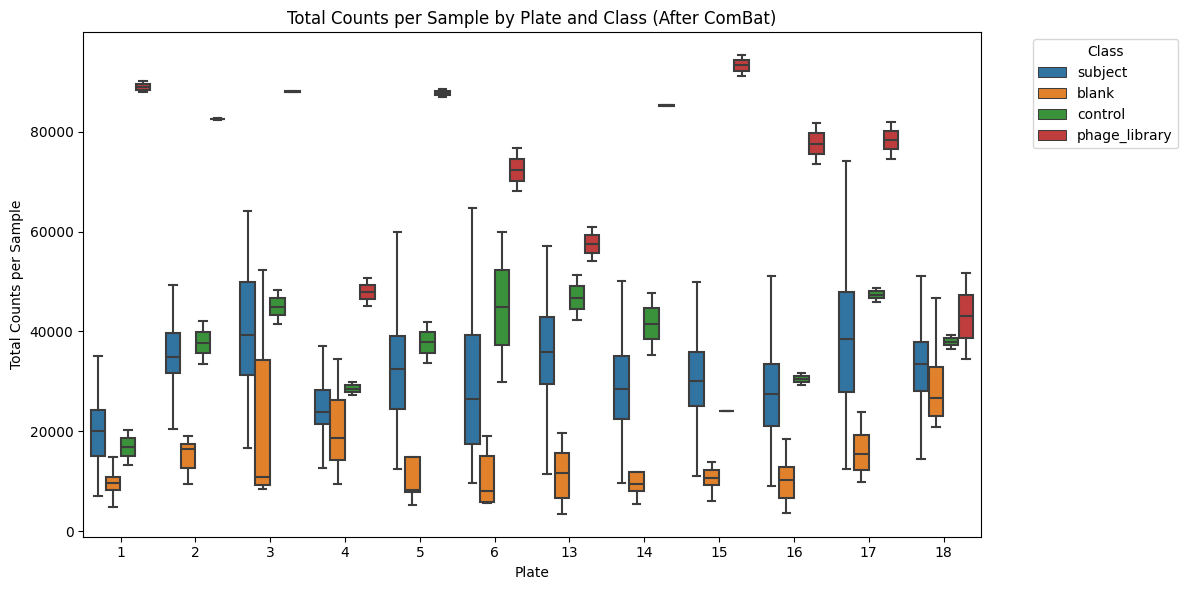

In [26]:
# Transpose back to samples as rows
data_combat = pd.DataFrame(combat_corrected, index=combat_input_T.index, columns=combat_input_T.columns).T

# Add plate/class info for plotting
data_combat_annot = data_combat.copy()
data_combat_annot['plate'] = data_combat_annot.index.map(manifest.set_index('sample')['plate'])
data_combat_annot['class'] = data_combat_annot.index.map(manifest.set_index('sample')['class'])

# Plot total counts after ComBat
plot_total_counts(data_combat_annot, "Total Counts per Sample by Plate and Class (After ComBat)")

In [27]:
# Map sample to subject
sample_to_subject = manifest.set_index('sample')['subject']

# Group by subject and take mean across replicates
data_scaled['subject'] = data_scaled.index.map(sample_to_subject)
data_final = data_scaled.groupby('subject').mean()

# Show a few rows of the final merged data
data_final.head()

,1,2,3,4,5,6,7,8,9,10,...,128278,128279,128280,128281,128282,128283,128284,128285,128286,128287
subject,,,,,,,,,,,,,,,,,,,,,
024JCM,0.0,0.334864,0.0,0.0,0.375454,0.0,0.636750,0.0,0.000000,0.0,...,0.385601,0.0,0.357696,0.482002,0.167432,0.000000,0.000000,0.000000,0.679876,0.000000
043MPL,0.0,1.061106,0.0,0.0,0.779666,0.0,0.680782,0.0,0.000000,0.0,...,0.661765,0.0,0.524848,0.844321,0.779666,1.159991,0.000000,0.593307,1.087729,0.000000
074KBP,0.0,0.000000,0.0,0.0,0.598697,0.0,0.887898,0.0,0.482002,0.0,...,0.000000,0.0,0.000000,0.000000,0.332327,0.459170,0.393212,0.398286,0.880287,0.877750
101VKC,0.0,0.296653,0.0,0.0,0.201572,0.0,0.448783,0.0,0.000000,0.0,...,0.715011,0.0,0.657962,0.540061,0.669372,0.000000,0.000000,0.000000,0.559078,0.578094
108741,0.0,0.384426,0.0,0.0,0.595149,0.0,0.000000,0.0,0.000000,0.0,...,0.854280,0.0,0.000000,0.703358,0.293303,0.945404,0.000000,0.000000,0.885604,0.498330


In [28]:
def compute_control_cv(data_annot, manifest):
    # Get control samples
    control_samples = manifest[manifest['class'] == 'control']['sample']
    if len(control_samples) == 0:
        return np.nan
    # Total counts per control sample
    total_counts = data_annot.loc[control_samples].drop(['plate', 'class'], axis=1).sum(axis=1)
    cv = total_counts.std() / total_counts.mean()
    return cv

cv_raw = compute_control_cv(data_annot, manifest)
cv_blank = compute_control_cv(data_blank_sub_annot, manifest)
cv_qn = compute_control_cv(data_qn_annot, manifest)
cv_scaled = compute_control_cv(data_scaled_annot, manifest)
cv_combat = compute_control_cv(data_combat_annot, manifest)

cv_results = pd.DataFrame({
    'Step': ['Raw', 'Blank Subtraction', 'Quantile Norm', 'Phage Lib Scaling', 'Combat'],
    'Control CV': [cv_raw, cv_blank, cv_qn, cv_scaled, cv_combat]
})

# What to look for: CV should decrease after normalization. Target CV < 0.2 for controls.

cv_results

,Step,Control CV
0,Raw,0.404821
1,Blank Subtraction,0.411270
2,Quantile Norm,0.300772
3,Phage Lib Scaling,0.405899
4,Combat,0.300772


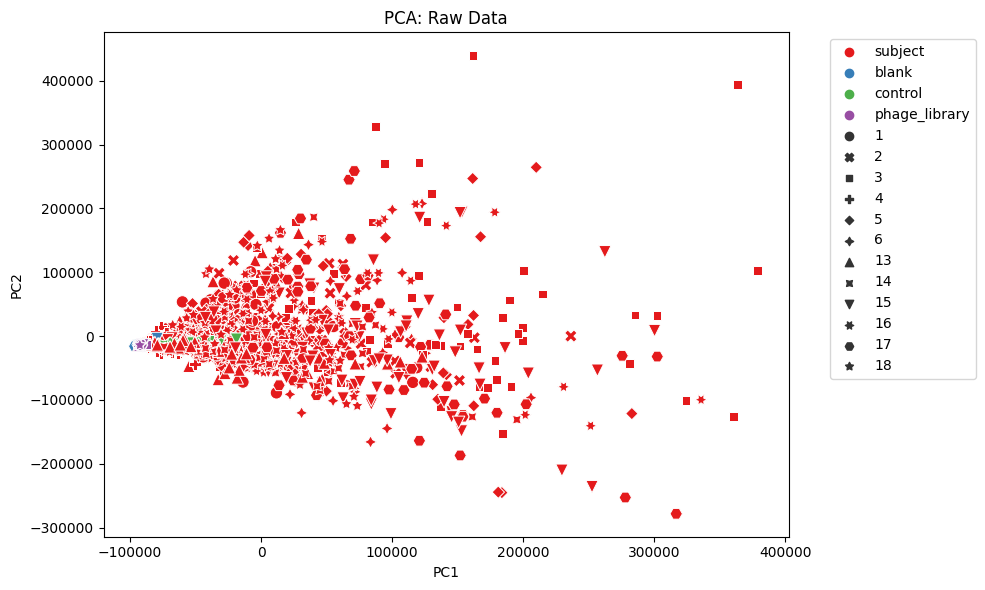

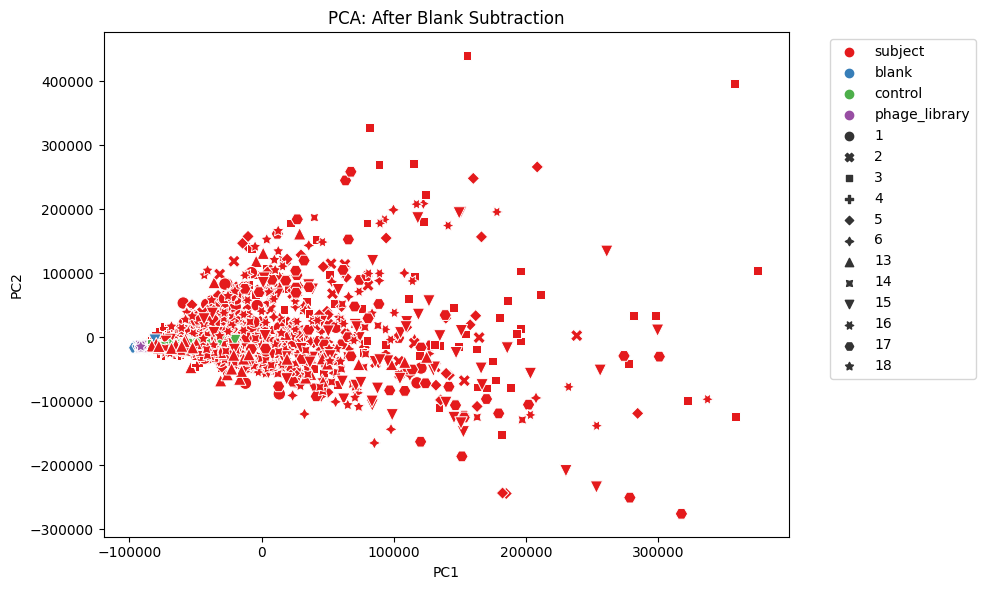

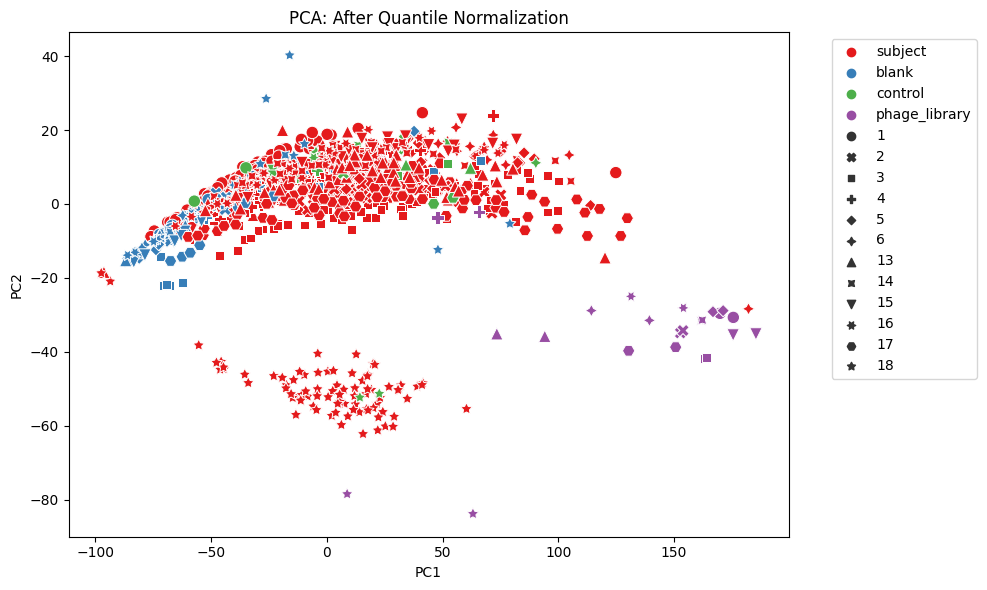

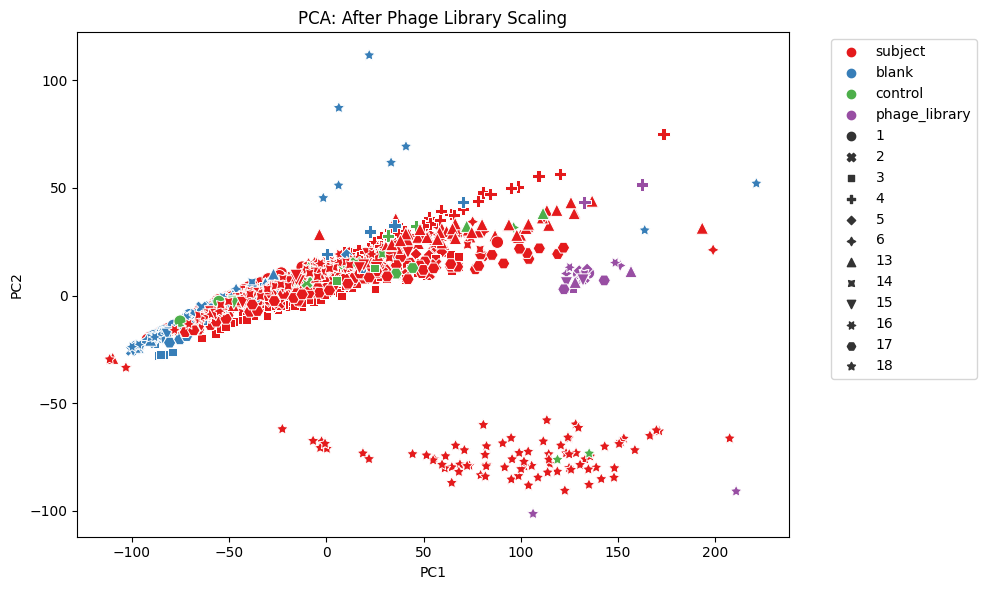

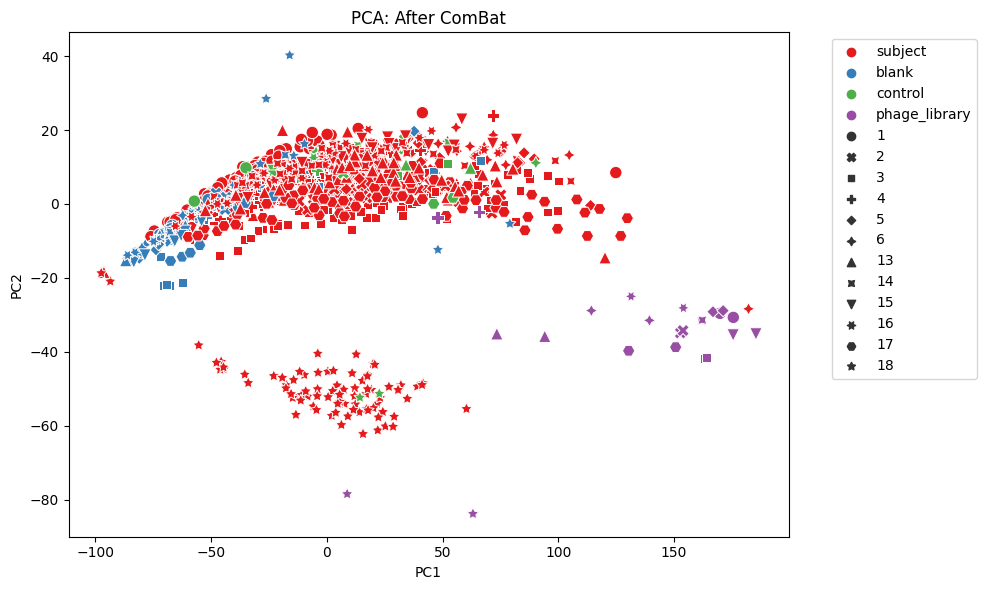

In [29]:
from sklearn.decomposition import PCA

def plot_pca(data_annot, manifest, title):
    # Remove annotation columns
    X = data_annot.drop(['plate', 'class'], axis=1).values
    y = data_annot['class'].values
    plates = data_annot['plate'].values
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, style=plates, s=80, palette='Set1')
    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# PCA plots for each step
plot_pca(data_annot, manifest, "PCA: Raw Data")
plot_pca(data_blank_sub_annot, manifest, "PCA: After Blank Subtraction")
plot_pca(data_qn_annot, manifest, "PCA: After Quantile Normalization")
plot_pca(data_scaled_annot, manifest, "PCA: After Phage Library Scaling")
plot_pca(data_combat_annot, manifest, "PCA: After ComBat")

In [30]:
data_final

,1,2,3,4,5,6,7,8,9,10,...,128278,128279,128280,128281,128282,128283,128284,128285,128286,128287
subject,,,,,,,,,,,,,,,,,,,,,
024JCM,0.000000,0.334864,0.000000,0.000000,0.375454,0.000000,0.636750,0.000000,0.000000,0.000000,...,0.385601,0.000000,0.357696,0.482002,0.167432,0.000000,0.000000,0.000000,0.679876,0.000000
043MPL,0.000000,1.061106,0.000000,0.000000,0.779666,0.000000,0.680782,0.000000,0.000000,0.000000,...,0.661765,0.000000,0.524848,0.844321,0.779666,1.159991,0.000000,0.593307,1.087729,0.000000
074KBP,0.000000,0.000000,0.000000,0.000000,0.598697,0.000000,0.887898,0.000000,0.482002,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.332327,0.459170,0.393212,0.398286,0.880287,0.877750
101VKC,0.000000,0.296653,0.000000,0.000000,0.201572,0.000000,0.448783,0.000000,0.000000,0.000000,...,0.715011,0.000000,0.657962,0.540061,0.669372,0.000000,0.000000,0.000000,0.559078,0.578094
108741,0.000000,0.384426,0.000000,0.000000,0.595149,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.854280,0.000000,0.000000,0.703358,0.293303,0.945404,0.000000,0.000000,0.885604,0.498330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PLib14,0.464244,0.958930,0.482002,0.958930,0.829550,0.000000,0.913266,0.464244,0.461707,0.918340,...,0.857456,0.413507,0.357696,0.882824,0.804182,0.834624,0.811792,0.842234,0.657044,0.416044
PLib15,0.876874,0.819996,0.440807,0.876874,0.734679,0.000000,0.829476,0.829476,0.424218,0.808146,...,0.756008,0.419478,0.805776,0.796297,0.805776,0.838955,0.817626,0.815256,0.774967,0.770228
PLib16,0.000000,0.973880,0.000000,1.053613,0.962489,0.000000,0.962489,0.512568,0.529654,1.013746,...,0.888452,0.506873,0.985270,0.922623,0.931166,0.922623,0.951099,0.000000,0.387274,0.498330


In [31]:
subject_manifest = manifest.drop('sample',axis='columns').sort_values(by='subject').drop_duplicates()
subject_manifest = subject_manifest.set_index('subject')
subject_manifest

,plate,class
subject,,
024JCM,14,subject
043MPL,13,subject
074KBP,14,subject
101VKC,13,subject
108741,16,subject
...,...,...
PLib14,14,phage_library
PLib15,15,phage_library
PLib16,16,phage_library


In [32]:
df=pd.DataFrame(subject_manifest.index)
df[df.duplicated()]

#these 2 are duplicated on different plates making this complicated.
# for this I should probably remove them from the dataset on the second plates
#	    subject
#520	D082062
#533	E045528

,subject


In [33]:
data_final_annot = subject_manifest.join(data_final)
data_final_annot

,plate,class,1,2,3,4,5,6,7,8,...,128278,128279,128280,128281,128282,128283,128284,128285,128286,128287
subject,,,,,,,,,,,,,,,,,,,,,
024JCM,14,subject,0.000000,0.334864,0.000000,0.000000,0.375454,0.000000,0.636750,0.000000,...,0.385601,0.000000,0.357696,0.482002,0.167432,0.000000,0.000000,0.000000,0.679876,0.000000
043MPL,13,subject,0.000000,1.061106,0.000000,0.000000,0.779666,0.000000,0.680782,0.000000,...,0.661765,0.000000,0.524848,0.844321,0.779666,1.159991,0.000000,0.593307,1.087729,0.000000
074KBP,14,subject,0.000000,0.000000,0.000000,0.000000,0.598697,0.000000,0.887898,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.332327,0.459170,0.393212,0.398286,0.880287,0.877750
101VKC,13,subject,0.000000,0.296653,0.000000,0.000000,0.201572,0.000000,0.448783,0.000000,...,0.715011,0.000000,0.657962,0.540061,0.669372,0.000000,0.000000,0.000000,0.559078,0.578094
108741,16,subject,0.000000,0.384426,0.000000,0.000000,0.595149,0.000000,0.000000,0.000000,...,0.854280,0.000000,0.000000,0.703358,0.293303,0.945404,0.000000,0.000000,0.885604,0.498330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PLib14,14,phage_library,0.464244,0.958930,0.482002,0.958930,0.829550,0.000000,0.913266,0.464244,...,0.857456,0.413507,0.357696,0.882824,0.804182,0.834624,0.811792,0.842234,0.657044,0.416044
PLib15,15,phage_library,0.876874,0.819996,0.440807,0.876874,0.734679,0.000000,0.829476,0.829476,...,0.756008,0.419478,0.805776,0.796297,0.805776,0.838955,0.817626,0.815256,0.774967,0.770228
PLib16,16,phage_library,0.000000,0.973880,0.000000,1.053613,0.962489,0.000000,0.962489,0.512568,...,0.888452,0.506873,0.985270,0.922623,0.931166,0.922623,0.951099,0.000000,0.387274,0.498330


In [34]:
from sklearn.metrics import silhouette_score

# Want LOW silhouette score when clustering by plate
# Want HIGH silhouette score when clustering by biology
score_plate = silhouette_score(data_final, data_final_annot['plate'])
score_biology = silhouette_score(data_final, data_final_annot['class'])   # not sure if this is even helpful

print(f"Silhouette score (plate): {score_plate:.3f}")  # Should be close to 0 ( How close? Is -0.083 "close"?
print(f"Silhouette score (biology): {score_biology:.3f}")  # Should be positive ( How positive? -0.010 isn't positive. )

Silhouette score (plate): -0.083
Silhouette score (biology): -0.010


In [35]:

score_plate = silhouette_score(data, data_annot['plate'])
score_biology = silhouette_score(data, data_annot['class'])   # not sure if this is even helpful

print(f"Silhouette score (plate): {score_plate:.3f}")  # Should be close to 0 ( How close? Is -0.083 "close"?
print(f"Silhouette score (biology): {score_biology:.3f}")  # Should be positive ( How positive? -0.010 isn't positive. )

Silhouette score (plate): -0.201
Silhouette score (biology): -0.292
